In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('usa_rain_prediction.csv')
df.head()

,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           73100 non-null  str    
 1   Location       73100 non-null  str    
 2   Temperature    73100 non-null  float64
 3   Humidity       73100 non-null  float64
 4   Wind Speed     73100 non-null  float64
 5   Precipitation  73100 non-null  float64
 6   Cloud Cover    73100 non-null  float64
 7   Pressure       73100 non-null  float64
 8   Rain Tomorrow  73100 non-null  int64  
dtypes: float64(6), int64(1), str(2)
memory usage: 5.0 MB


In [4]:
df.shape

(73100, 9)

In [5]:
# Feature in X
X=df.drop(columns='Rain Tomorrow')
X

,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859
...,...,...,...,...,...,...,...,...
73095,2025-12-27,Washington D.C.,40.614393,65.099438,28.778327,0.000000,54.168514,977.083747
73096,2025-12-28,Washington D.C.,52.641643,30.610525,12.282890,0.871000,22.068055,980.591675
73097,2025-12-29,Washington D.C.,56.492591,96.740232,2.894762,1.191956,52.336048,1016.469174
73098,2025-12-30,Washington D.C.,65.748956,63.900004,24.632400,0.483421,76.785280,1032.396146


In [6]:
X.shape

(73100, 8)

In [7]:
# Target = y
y=df['Rain Tomorrow']
y

0        0
1        0
2        1
3        0
4        0
        ..
73095    0
73096    0
73097    1
73098    1
73099    0
Name: Rain Tomorrow, Length: 73100, dtype: int64

In [8]:
y.shape

(73100,)

In [9]:
X.describe()

,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,65.182270,59.875041,15.017946,0.390635,54.942807,1005.176013
std,20.205793,23.066115,8.668729,0.474833,25.982487,20.203889
min,30.000766,20.000272,0.000712,0.000000,10.000856,970.000919
25%,47.678968,39.800732,7.485182,0.000000,32.318668,987.697646
50%,65.294949,59.887840,15.102495,0.196909,55.011121,1005.284188
75%,82.636570,79.835990,22.551794,0.673177,77.412469,1022.727410
max,99.997393,99.999025,29.999017,3.078090,99.998957,1039.999765


In [10]:
df['Location'].value_counts()

Location
New York           3655
Los Angeles        3655
Chicago            3655
Houston            3655
Phoenix            3655
Philadelphia       3655
San Antonio        3655
San Diego          3655
Dallas             3655
San Jose           3655
Austin             3655
Jacksonville       3655
Fort Worth         3655
Columbus           3655
Indianapolis       3655
Charlotte          3655
San Francisco      3655
Seattle            3655
Denver             3655
Washington D.C.    3655
Name: count, dtype: int64

In [11]:
num_cols=X.select_dtypes(include=[np.number]).columns.to_list()
num_cols

['Temperature',
 'Humidity',
 'Wind Speed',
 'Precipitation',
 'Cloud Cover',
 'Pressure']

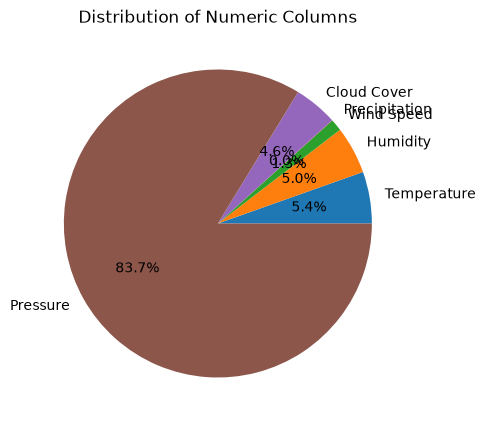

In [17]:
data=df[num_cols]
fig=plt.figure(figsize=(8,5))
plt.pie(data.sum(), labels=num_cols, autopct='%1.1f%%' )
plt.title('Distribution of Numeric Columns')
plt.tight_layout
plt.show()